# Inspect LanceDB VPT Rollout Shards

Use this notebook to inspect shards written by `lancedb_rollout.py`. It discovers `*.done.json` markers, opens the corresponding `*.lancedb` directories, previews schemas/rows, summarizes episodes, and decodes JPEG observation frames.

In [1]:
from pathlib import Path
import base64
import io
import json

import lancedb
import numpy as np
import pandas as pd
import pyarrow as pa
from IPython.display import HTML, display
from PIL import Image, ImageDraw

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

In [2]:
import os
os.chdir("..")

## Configure Dataset Path

Set `DATA_DIR` to the directory containing your shard folders and `*.done.json` marker files. For local debugging this defaults to `debug_shards`.

In [3]:
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "debug_shards"
TABLE_NAME = "transitions"
INCLUDE_PARTIAL = False

DATA_DIR

PosixPath('/home/eric/Video-Pre-Training/debug_shards')

## Discover Shards

In [4]:
def _resolve_shard_uri(marker_path: Path, uri: str | None) -> Path | None:
    if not uri:
        return None
    raw = Path(uri)
    candidates = [raw]
    if not raw.is_absolute():
        candidates.extend([
            marker_path.parent / raw,
            marker_path.parent / raw.name,
            Path.cwd() / raw,
        ])
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return raw


def discover_shards(data_dir: Path, include_partial: bool = False) -> pd.DataFrame:
    rows = []
    for marker in sorted(data_dir.glob("*.done.json")):
        metadata = json.loads(marker.read_text())
        shard_dir = _resolve_shard_uri(marker, metadata.get("uri"))
        rows.append({
            "status": "done",
            "marker": str(marker),
            "shard_dir": str(shard_dir) if shard_dir else None,
            "shard_id": metadata.get("shard_id"),
            "collector_id": metadata.get("collector_id"),
            "num_episodes": metadata.get("num_episodes"),
            "num_steps": metadata.get("num_steps"),
            "table_name": metadata.get("table_name", TABLE_NAME),
            "metadata": metadata,
        })

    if include_partial:
        for shard_dir in sorted(data_dir.glob("*.partial")):
            rows.append({
                "status": "partial",
                "marker": None,
                "shard_dir": str(shard_dir.resolve()),
                "shard_id": shard_dir.stem,
                "collector_id": None,
                "num_episodes": None,
                "num_steps": None,
                "table_name": TABLE_NAME,
                "metadata": {},
            })

    return pd.DataFrame(rows)


shards = discover_shards(DATA_DIR, include_partial=INCLUDE_PARTIAL)
display(shards.drop(columns=["metadata"], errors="ignore"))
print(f"found {len(shards)} shard(s) under {DATA_DIR}")

,status,marker,shard_dir,shard_id,collector_id,num_episodes,num_steps,table_name
0,done,/home/eric/Video-Pre-Training/debug_shards/20260619T192629Z_Eric_PC_2e0922d6_000000.done.json,/home/eric/Video-Pre-Training/debug_shards/20260619T192629Z_Eric_PC_2e0922d6_000000.lancedb,20260619T192629Z_Eric_PC_2e0922d6_000000,None,1,147,transitions
1,done,/home/eric/Video-Pre-Training/debug_shards/20260619T193515Z_Eric_PC_43da85ec_000000.done.json,/home/eric/Video-Pre-Training/debug_shards/20260619T193515Z_Eric_PC_43da85ec_000000.lancedb,20260619T193515Z_Eric_PC_43da85ec_000000,None,1,1000,transitions
2,done,/home/eric/Video-Pre-Training/debug_shards/20260619T195931Z_Eric_PC_46350f8e_000000.done.json,/home/eric/Video-Pre-Training/debug_shards/20260619T195931Z_Eric_PC_46350f8e_000000.lancedb,20260619T195931Z_Eric_PC_46350f8e_000000,None,1,129,transitions
3,done,/home/eric/Video-Pre-Training/debug_shards/20260619T201314Z_Eric_PC_3273a241_000000.done.json,/home/eric/Video-Pre-Training/debug_shards/20260619T201314Z_Eric_PC_3273a241_000000.lancedb,20260619T201314Z_Eric_PC_3273a241_000000,None,1,4000,transitions


found 4 shard(s) under /home/eric/Video-Pre-Training/debug_shards


## Open One Shard

In [5]:
SHARD_INDEX = 3

if shards.empty:
    raise FileNotFoundError(f"No shards found in {DATA_DIR}. Set DATA_DIR or enable INCLUDE_PARTIAL.")

shard_row = shards.iloc[SHARD_INDEX]
shard_dir = Path(shard_row["shard_dir"])
table_name = shard_row.get("table_name") or TABLE_NAME

db = lancedb.connect(str(shard_dir))
table = db.open_table(table_name)
arrow_table = table.to_arrow()

print("shard_dir:", shard_dir)
print("table_name:", table_name)
print("rows:", table.count_rows())
print("columns:", len(table.schema.names))

shard_dir: /home/eric/Video-Pre-Training/debug_shards/20260619T201314Z_Eric_PC_3273a241_000000.lancedb
table_name: transitions
rows: 4000
columns: 49


## Schema

In [6]:
schema_df = pd.DataFrame(
    [{"name": field.name, "type": str(field.type)} for field in table.schema]
)
display(schema_df)

jpeg_cols = [field.name for field in table.schema if field.name.endswith("_jpeg")]
action_cols = [field.name for field in table.schema if field.name.startswith("action_")]
obs_cols = [field.name for field in table.schema if field.name.startswith("obs_")]

print("jpeg columns:", jpeg_cols)
print("action columns:", action_cols[:20], "..." if len(action_cols) > 20 else "")
print("obs columns:", obs_cols[:20], "..." if len(obs_cols) > 20 else "")

,name,type
0,episode_idx,int32
1,step_idx,int32
2,obs_pov_jpeg,binary
3,action_attack,fixed_size_list<item: int64>[1]
4,action_back,fixed_size_list<item: int64>[1]
5,action_forward,fixed_size_list<item: int64>[1]
6,action_jump,fixed_size_list<item: int64>[1]
7,action_left,fixed_size_list<item: int64>[1]
8,action_right,fixed_size_list<item: int64>[1]
9,action_sneak,fixed_size_list<item: int64>[1]


jpeg columns: ['obs_pov_jpeg']
action columns: ['action_attack', 'action_back', 'action_forward', 'action_jump', 'action_left', 'action_right', 'action_sneak', 'action_sprint', 'action_use', 'action_drop', 'action_inventory', 'action_hotbar_1', 'action_hotbar_2', 'action_hotbar_3', 'action_hotbar_4', 'action_hotbar_5', 'action_hotbar_6', 'action_hotbar_7', 'action_hotbar_8', 'action_hotbar_9'] ...
obs columns: ['obs_pov_jpeg'] 


## Row Preview Without JPEG Blobs

In [7]:
def to_pandas_preview(table, limit: int = 40, include_blobs: bool = False) -> pd.DataFrame:
    binary_cols = {field.name for field in table.schema if pa.types.is_binary(field.type)}
    keep_cols = table.schema.names if include_blobs else [c for c in table.schema.names if c not in binary_cols]
    arrow = table.to_arrow().select(keep_cols).slice(0, limit)
    return arrow.to_pandas()


preview = to_pandas_preview(table, limit=40, include_blobs=False)
display(preview)

,episode_idx,step_idx,action_attack,action_back,action_forward,action_jump,action_left,action_right,action_sneak,action_sprint,action_use,action_drop,action_inventory,action_hotbar_1,action_hotbar_2,action_hotbar_3,action_hotbar_4,action_hotbar_5,action_hotbar_6,action_hotbar_7,action_hotbar_8,action_hotbar_9,action_camera,idm_action_attack,idm_action_back,idm_action_forward,idm_action_jump,idm_action_left,idm_action_right,idm_action_sneak,idm_action_sprint,idm_action_use,idm_action_drop,idm_action_inventory,idm_action_hotbar_1,idm_action_hotbar_2,idm_action_hotbar_3,idm_action_hotbar_4,idm_action_hotbar_5,idm_action_hotbar_6,idm_action_hotbar_7,idm_action_hotbar_8,idm_action_hotbar_9,idm_action_camera,reward,terminated,truncated,policy_idm_cross_entropy
0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[1.6094986, -10.0]",[0],[0],[0],[0],[0],[0],[0],[1],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[3.2153692, -10.0]",0.0,False,False,10.897745
1,0,1,[0],[0],[1],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[3.2153692, -10.0]",[0],[0],[1],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[1.6094986, -5.809483]",0.0,False,False,7.884232
2,0,2,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[0.0, -1.6094986]",[0],[0],[1],[0],[0],[0],[0],[1],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[0.0, -1.6094986]",0.0,False,False,13.392776
3,0,3,[0],[0],[1],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[1.6094986, -10.0]",[0],[0],[1],[0],[0],[0],[0],[1],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[1.6094986, -10.0]",0.0,False,False,7.315528
4,0,4,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[1.6094986, -10.0]",[0],[0],[1],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[0.6153943, -5.809483]",0.0,False,False,4.566866
5,0,5,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[0.0, -3.2153692]",[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[-0.6153943, -5.809483]",0.0,False,False,5.814374
6,0,6,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[-1.6094986, -10.0]",[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[-1.6094986, -10.0]",0.0,False,False,3.324249
7,0,7,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[-1.6094986, -10.0]",[0],[0],[0],[0],[0],[0],[0],[1],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[-0.6153943, -5.809483]",0.0,False,False,9.735611
8,0,8,[0],[0],[1],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[0.0, 1.6094986]",[0],[0],[1],[0],[0],[0],[0],[1],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[0.0, 0.6153943]",0.0,False,False,11.143888
9,0,9,[0],[0],[1],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[0.0, 0.0]",[0],[0],[1],[0],[0],[0],[0],[1],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[0.0, 0.0]",0.0,False,False,21.617527


## Episode Summary

In [8]:
summary_cols = [
    c for c in ["episode_idx", "step_idx", "reward", "terminated", "truncated"]
    if c in table.schema.names
]
summary_df = table.to_arrow().select(summary_cols).to_pandas()

episode_summary = (
    summary_df.groupby("episode_idx")
    .agg(
        steps=("step_idx", "count"),
        first_step=("step_idx", "min"),
        last_step=("step_idx", "max"),
        total_reward=("reward", "sum"),
        terminated=("terminated", "max"),
        truncated=("truncated", "max"),
    )
    .reset_index()
)
display(episode_summary)

marker_metadata = shard_row.get("metadata", {})
if marker_metadata:
    print(json.dumps({k: marker_metadata.get(k) for k in ["shard_id", "collector_id", "env", "model_path", "weights_path", "max_steps"]}, indent=2))
    if marker_metadata.get("episode_summaries"):
        display(pd.DataFrame(marker_metadata["episode_summaries"]))

,episode_idx,steps,first_step,last_step,total_reward,terminated,truncated
0,0,4000,0,3999,0.0,False,True


{
  "shard_id": "20260619T201314Z_Eric_PC_3273a241_000000",
  "collector_id": null,
  "env": null,
  "model_path": null,
  "weights_path": null,
  "max_steps": null
}


## Decode Observation Frames

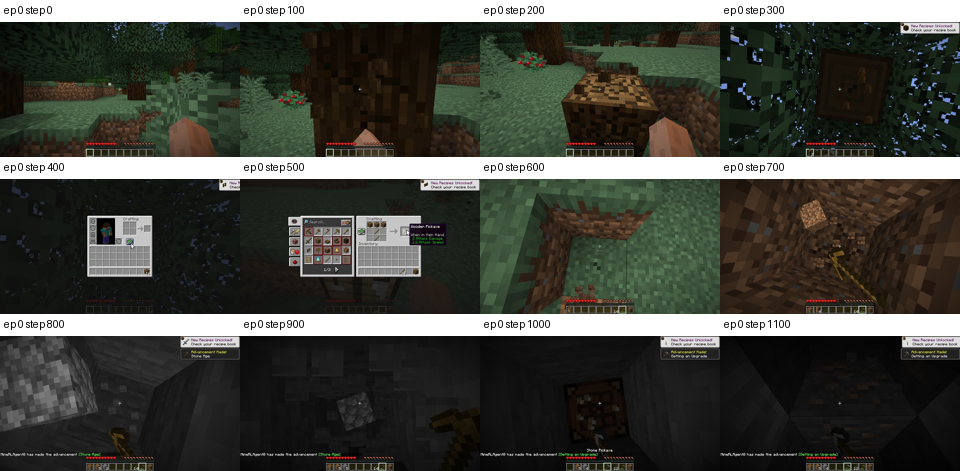

In [9]:
def blob_to_bytes(blob) -> bytes:
    if isinstance(blob, bytes):
        return blob
    if isinstance(blob, bytearray):
        return bytes(blob)
    if isinstance(blob, memoryview):
        return blob.tobytes()
    if hasattr(blob, "read"):
        return blob.read()
    return bytes(blob)


def decode_jpeg(blob) -> Image.Image:
    return Image.open(io.BytesIO(blob_to_bytes(blob))).convert("RGB")


def make_contact_sheet(frames, labels=None, columns: int = 4, thumb_width: int = 240) -> Image.Image:
    if not frames:
        raise ValueError("No frames to display")
    thumbs = []
    for frame in frames:
        frame = frame.copy()
        scale = thumb_width / frame.width
        thumb_height = int(round(frame.height * scale))
        frame.thumbnail((thumb_width, thumb_height))
        thumbs.append(frame)

    label_height = 22 if labels else 0
    cell_w = max(t.width for t in thumbs)
    cell_h = max(t.height for t in thumbs) + label_height
    rows = int(np.ceil(len(thumbs) / columns))
    sheet = Image.new("RGB", (columns * cell_w, rows * cell_h), "white")
    draw = ImageDraw.Draw(sheet)
    for idx, thumb in enumerate(thumbs):
        x = (idx % columns) * cell_w
        y = (idx // columns) * cell_h
        sheet.paste(thumb, (x, y + label_height))
        if labels:
            draw.text((x + 4, y + 4), str(labels[idx]), fill=(0, 0, 0))
    return sheet


def show_episode_frames(table, episode_idx: int = 0, image_col: str | None = None, stride: int = 100, max_frames: int = 12):
    if image_col is None:
        candidates = [c for c in table.schema.names if c.endswith("_jpeg")]
        if not candidates:
            raise ValueError("No *_jpeg columns found")
        image_col = "obs_pov_jpeg" if "obs_pov_jpeg" in candidates else candidates[0]

    cols = ["episode_idx", "step_idx", image_col]
    df = table.to_arrow().select(cols).to_pandas()
    df = df[df["episode_idx"] == episode_idx].sort_values("step_idx")
    df = df.iloc[::stride].head(max_frames)
    frames = [decode_jpeg(blob) for blob in df[image_col]]
    labels = [f"ep {int(row.episode_idx)} step {int(row.step_idx)}" for row in df.itertuples()]
    display(make_contact_sheet(frames, labels=labels))


show_episode_frames(table, episode_idx=0, stride=100, max_frames=12)

## Inspect Actions

In [12]:
action_preview_cols = ["episode_idx", "step_idx"] + action_cols
action_preview_cols = [c for c in action_preview_cols if c in table.schema.names]
actions_df = table.to_arrow().select(action_preview_cols).slice(0, 50).to_pandas()
display(actions_df)

for col in action_cols:
    counts = actions_df[col].value_counts(dropna=False).head(10)
    print(f"\n{col}")
    display(counts.to_frame("count"))

,episode_idx,step_idx,action_attack,action_back,action_forward,action_jump,action_left,action_right,action_sneak,action_sprint,action_use,action_drop,action_inventory,action_hotbar_1,action_hotbar_2,action_hotbar_3,action_hotbar_4,action_hotbar_5,action_hotbar_6,action_hotbar_7,action_hotbar_8,action_hotbar_9,action_camera
0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[-3.2153692, 0.6153943]"
1,0,1,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[0.0, -1.6094986]"
2,0,2,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[3.2153692, -10.0]"
3,0,3,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[0.0, -10.0]"
4,0,4,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[0.0, -0.6153943]"
5,0,5,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[0.6153943, -0.6153943]"
6,0,6,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[1.6094986, -3.2153692]"
7,0,7,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[1.6094986, -10.0]"
8,0,8,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[0.6153943, -10.0]"
9,0,9,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],"[1.6094986, -10.0]"



action_attack


,count
action_attack,
[0],40
[1],10



action_back


,count
action_back,
[0],44
[1],6


...

,count
action_hotbar_8,
[0],50



action_hotbar_9


,count
action_hotbar_9,
[0],50



action_camera


,count
action_camera,
"[-3.2153692, 0.6153943]",1
"[0.0, -1.6094986]",1
"[3.2153692, -10.0]",1
"[0.0, -10.0]",1
"[0.0, -0.6153943]",1
"[0.6153943, -0.6153943]",1
"[1.6094986, -3.2153692]",1
"[1.6094986, -10.0]",1
"[0.6153943, -10.0]",1


## Load All Done Shards Into One Arrow Table

Use this only when the combined data is small enough for memory.

In [ ]:
def load_done_shards_as_arrow(shards_df: pd.DataFrame) -> pa.Table:
    tables = []
    for row in shards_df.itertuples():
        if row.status != "done":
            continue
        db = lancedb.connect(row.shard_dir)
        table_name = row.table_name or TABLE_NAME
        tables.append(db.open_table(table_name).to_arrow())
    if not tables:
        raise ValueError("No done shards to load")
    return pa.concat_tables(tables, promote_options="default")


# Uncomment when needed.
# all_arrow = load_done_shards_as_arrow(shards)
# print(all_arrow.num_rows, all_arrow.num_columns)